# Brief Score Matching Notebook

This notebook is a compact implementation of **denoising score matching (DSM)**.

Core idea:
$$ s_\theta(\tilde{x}, \sigma) \approx \nabla_{\tilde{x}} \log q_\sigma(\tilde{x}) $$

Instead of directly learning a density \(p(x)\), we learn a **vector field** that points noisy samples back toward higher-density regions.

For Gaussian corruption,

$$
\tilde{x}=x+\sigma\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I)
$$

the conditional score target is tractable:

$$
\nabla_{\tilde{x}}\log q(\tilde{x}\mid x) =
-\frac{\tilde{x}-x}{\sigma^2}
$$

## What is different from DDPM?

| Item | DDPM-style diffusion | Score matching / DSM |
|---|---|---|
| Model output | usually predicts noise $(\epsilon_\theta(x_t,t))$ | predicts score $s_\theta(\tilde{x},\sigma)$ |
| Target | $\epsilon$ | $(-(\tilde{x}-x)/\sigma^2)$ |
| Meaning | recover the noise added to the sample | vector direction toward higher probability |
| Relation | $x_t=x_0+\sigma\epsilon$ in simplified form | $s^\star(\tilde{x},\sigma)=-\epsilon/\sigma$ |

So the difference is mostly **parameterization**:

$$
\text{noise target: } \epsilon
\qquad\Longleftrightarrow\qquad
\text{score target: } -\frac{\epsilon}{\sigma}
$$

In [3]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

seed = 727
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Toy data distribution

Use a simple 2D mixture. We do not need images here because the score field is easiest to see in 2D.

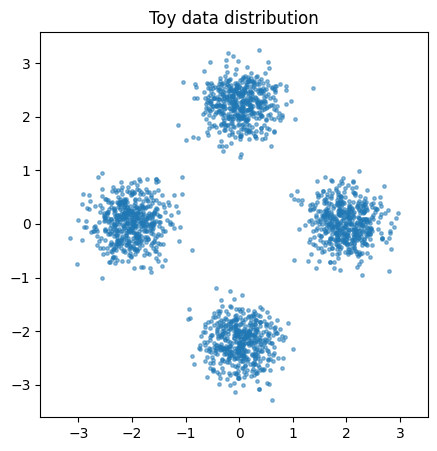

In [4]:
def sample_data(n: int) -> torch.Tensor:
    centers = torch.tensor(
        [[-2.0, 0.0], [2.0, 0.0], [0.0, 2.2], [0.0, -2.2]],
        dtype=torch.float32,
    )
    idx = torch.randint(0, len(centers), (n,))
    x = centers[idx] + 0.35 * torch.randn(n, 2)
    return x


x = sample_data(2_000)

plt.figure(figsize=(5, 5))
plt.scatter(x[:, 0], x[:, 1], s=6, alpha=0.5)
plt.title("Toy data distribution")
plt.axis("equal")
plt.show()

## 2. Gaussian corruption and DSM target

DSM gives us a supervised target without knowing \(p_{\text{data}}(x)\).

$$
\tilde{x}=x+\sigma\epsilon
$$

$$
s^\star(\tilde{x},\sigma)
=
-\frac{\tilde{x}-x}{\sigma^2}
=
-\frac{\epsilon}{\sigma}
$$

In [5]:
def corrupt(x: torch.Tensor, sigma: torch.Tensor):
    eps = torch.randn_like(x)
    x_noisy = x + sigma * eps
    score_target = -(x_noisy - x) / (sigma ** 2)
    noise_target = eps
    return x_noisy, score_target, noise_target


sigma = torch.full((8, 1), 0.5)
clean = sample_data(8)
noisy, score_target, noise_target = corrupt(clean, sigma)

print("clean shape:       ", clean.shape)
print("noisy shape:       ", noisy.shape)
print("score target shape:", score_target.shape)
print()
print("DDPM-like noise target epsilon[0]:", noise_target[0].numpy())
print("DSM score target score[0]:       ", score_target[0].numpy())
print("Check relation score = -epsilon/sigma:")
print((-noise_target[0] / sigma[0]).numpy())

clean shape:        torch.Size([8, 2])
noisy shape:        torch.Size([8, 2])
score target shape: torch.Size([8, 2])

DDPM-like noise target epsilon[0]: [-0.58880734  0.55893224]
DSM score target score[0]:        [ 1.1776147 -1.1178645]
Check relation score = -epsilon/sigma:
[ 1.1776147 -1.1178645]


## 3. Tiny score network

The network receives:

$$
(\tilde{x}_1,\tilde{x}_2,\log\sigma)
$$

and predicts a 2D score vector:

$$
s_\theta(\tilde{x},\sigma)\in\mathbb{R}^2
$$

![score matching model](../assets/score_matching_net.svg)

In [9]:
class ScoreNet(nn.Module):
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x_noisy: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        log_sigma = torch.log(sigma)
        inp = torch.cat([x_noisy, log_sigma], dim=1)
        return self.net(inp)

model = ScoreNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

<div style="text-align: center;">
  <img src="../assets/sm_network_architecture.gif" alt="sm_network_architecture" width="50%"/>
</div>

## 4. Train with denoising score matching

The whole objective is just MSE against the analytic Gaussian-corruption score:

$$
\mathcal{L}_{DSM}
=
\mathbb{E}_{x,\tilde{x}}
\left\|
s_\theta(\tilde{x},\sigma)
+
\frac{\tilde{x}-x}{\sigma^2}
\right\|^2
$$

step  300 | loss 1.2126
step  600 | loss 1.1869
step  900 | loss 1.1715
step 1200 | loss 1.1715


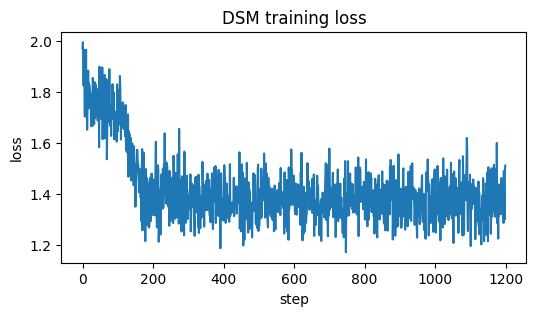

In [10]:
batch_size = 512
steps = 1_200

# multi-noise training: same idea as using many diffusion timesteps, but written directly with sigma.
sigma_min = 0.05
sigma_max = 1.5

losses = []

for step in range(steps):
    x = sample_data(batch_size).to(device)

    # log-uniform sigma sampling
    u = torch.rand(batch_size, 1, device=device)
    sigma = sigma_min * (sigma_max / sigma_min) ** u

    x_noisy, score, _ = corrupt(x, sigma)
    pred_score = model(x_noisy, sigma)

    # Optional sigma^2 weighting keeps small sigmas from dominating too hard.
    loss = ((pred_score - score) ** 2).sum(dim=1)
    loss = (sigma.squeeze() ** 2 * loss).mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (step + 1) % 300 == 0:
        print(f"step {step + 1:4d} | loss {min(losses):.4f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title("DSM training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

## 5. Visualize the learned score field

Arrows show the predicted direction of increasing log-density.

Larger $\sigma$ means a smoother, more global vector field.  
Smaller $\sigma$ means a sharper, more local vector field.

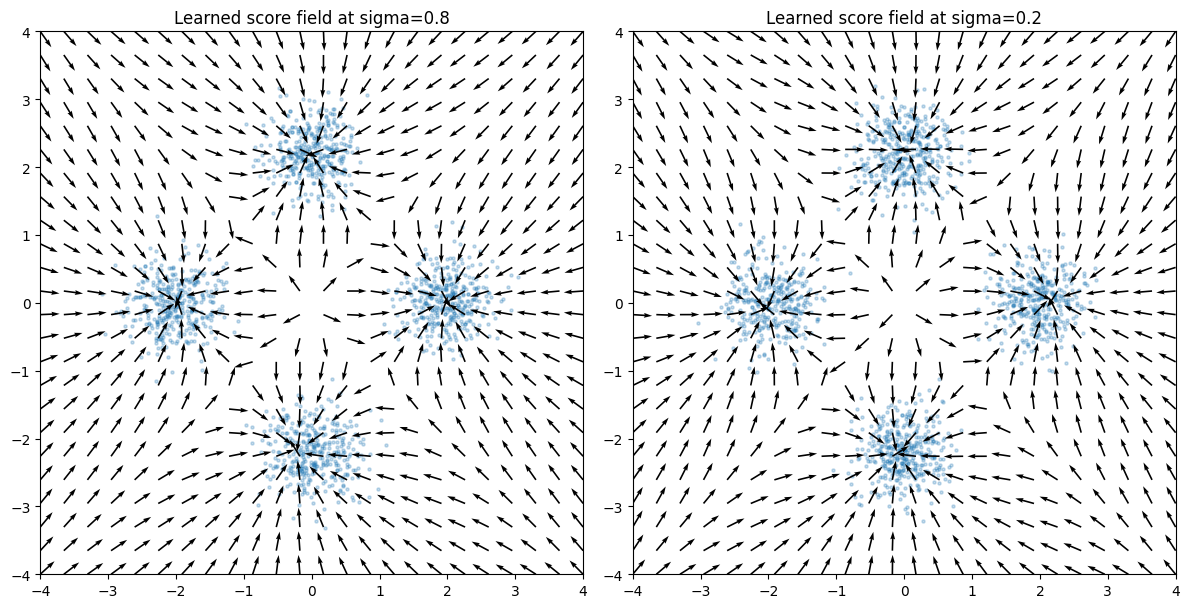

In [11]:
@torch.no_grad()
def create_score_field_plot(
    model: nn.Module,
    sigma_value: float = 0.35,
    grid_size: int = 24,
    ax=None,
    ):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
        
    xs = torch.linspace(-4, 4, grid_size)
    ys = torch.linspace(-4, 4, grid_size)
    xx, yy = torch.meshgrid(xs, ys, indexing="xy")
    points = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

    sigma = torch.full((points.shape[0], 1), sigma_value, device=device)
    score = model(points, sigma).cpu()

    score_norm = score / (score.norm(dim=1, keepdim=True) + 1e-8)

    data = sample_data(1_500)

    ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.25)
    ax.quiver(
        points[:, 0].cpu(),
        points[:, 1].cpu(),
        score_norm[:, 0],
        score_norm[:, 1],
        angles="xy",
        scale_units="xy",
        scale=3.5,
        width=0.003,
    )
    ax.set_title(f"Learned score field at sigma={sigma_value}")
    ax.axis("equal")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal", adjustable="box")
    return ax


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
create_score_field_plot(model, sigma_value=0.8, ax=axes[0])
create_score_field_plot(model, sigma_value=0.2, ax=axes[1])

plt.tight_layout()
plt.show()

## 6. One-step denoising

Since

$$
s^\star(\tilde{x},\sigma)=-\frac{\tilde{x}-x}{\sigma^2}
$$

we can rearrange:

$$
x \approx \tilde{x} + \sigma^2 s_\theta(\tilde{x},\sigma)
$$

This is **not a full sampler**. It only shows what the score vector means.

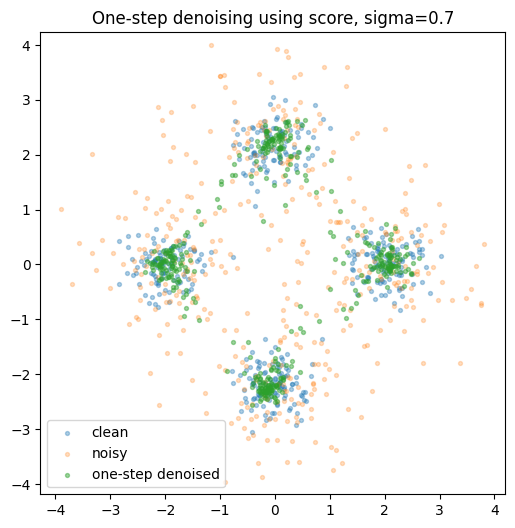

In [15]:
@torch.no_grad()
def show_one_step_denoising(sigma_value: float = 0.7, n: int = 400):
    x = sample_data(n).to(device)
    sigma = torch.full((n, 1), sigma_value, device=device)
    x_noisy, _, _ = corrupt(x, sigma)

    score = model(x_noisy, sigma)
    x_denoised = x_noisy + sigma ** 2 * score

    x = x.cpu()
    x_noisy = x_noisy.cpu()
    x_denoised = x_denoised.cpu()

    plt.figure(figsize=(6, 6))
    plt.scatter(x[:, 0], x[:, 1], s=8, alpha=0.35, label="clean")
    plt.scatter(x_noisy[:, 0], x_noisy[:, 1], s=8, alpha=0.25, label="noisy")
    plt.scatter(x_denoised[:, 0], x_denoised[:, 1], s=8, alpha=0.45, label="one-step denoised")
    plt.title(f"One-step denoising using score, sigma={sigma_value}")
    plt.legend()
    plt.axis("equal")
    plt.show()


show_one_step_denoising(sigma_value=0.7)

## Minimal takeaway

- **Score matching** learns a vector field: where should \(x\) move to become more likely?
- **Denoising score matching** makes the target available by adding Gaussian noise.
- **DDPM noise prediction** and **score prediction** are closely related:

$$
s^\star(x_t,t)
=
-\frac{\epsilon}{\sqrt{1-\bar{\alpha}_t}}
$$

Therefore, predicting $\epsilon$ is a reparameterized way of learning the score.